In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('poly.csv')
df.head()

,Area_sqft,Bedrooms,Age_years,Distance_from_city_km,House_Price_Lakh
0,650,1,18,14,31
1,720,1,15,13,36
2,800,2,12,12,43
3,850,2,10,11,49
4,900,2,8,10,56


In [3]:
X=df[['Area_sqft']]
y=df[['House_Price_Lakh']]

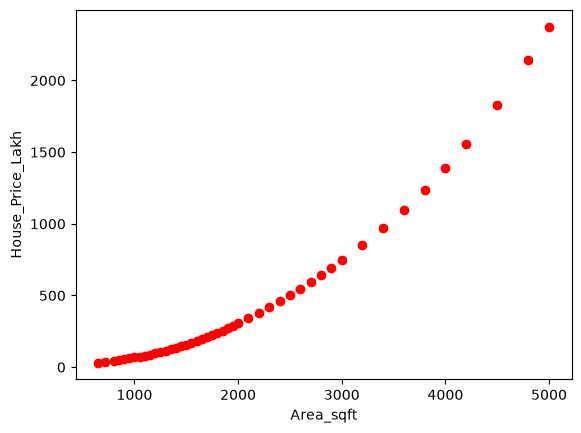

In [5]:
plt.scatter(X,y,color='red')
plt.xlabel('Area_sqft')
plt.ylabel('House_Price_Lakh')
plt.show()

In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# ==========================================
# 1. Load Dataset
# ==========================================

df = pd.read_csv("poly.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

# ==========================================
# 2. Select Features and Target
# ==========================================

X = df[["Area_sqft"]]
y = df["House_Price_Lakh"]

# ==========================================
# 3. Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# 4. Create Polynomial Features
# ==========================================

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# ==========================================
# 5. Create Model
# ==========================================

model = LinearRegression()

# ==========================================
# 6. Train Model
# ==========================================

model.fit(X_train_poly, y_train)

# ==========================================
# 7. Prediction
# ==========================================

y_pred = model.predict(X_test_poly)

# ==========================================
# 8. Evaluation
# ==========================================

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

print("\n========== MODEL PERFORMANCE ==========")

print("R2 Score :", r2)
print("MAE      :", mae)
print("MSE      :", mse)
print("RMSE     :", rmse)

# ==========================================
# 9. Predict New House Price
# ==========================================

new_house = pd.DataFrame({
    "Area_sqft": [2000]
})

new_house_poly = poly.transform(new_house)

prediction = model.predict(new_house_poly)

print("\n======================================")
print("Area:", new_house["Area_sqft"].iloc[0], "sqft")
print("Predicted House Price:",
      round(prediction[0], 2), "Lakh")
print("======================================")

# ==========================================
# 10. Polynomial Equation
# ==========================================

print("\nPolynomial Coefficients:")
print(model.coef_)

print("\nIntercept:")
print(model.intercept_)

First 5 rows:
   Area_sqft  Bedrooms  Age_years  Distance_from_city_km  House_Price_Lakh
0        650         1         18                     14                31
1        720         1         15                     13                36
2        800         2         12                     12                43
3        850         2         10                     11                49
4        900         2          8                     10                56

Dataset Shape:
(46, 5)

========== MODEL PERFORMANCE ==========
R2 Score : 0.9994878182528032
MAE      : 10.825335603299436
MSE      : 232.2238392843828
RMSE     : 15.238892324719103

Area: 2000 sqft
Predicted House Price: 295.73 Lakh

Polynomial Coefficients:
[ 0.         -0.11151021  0.00011252]

Intercept:
68.65109102610478


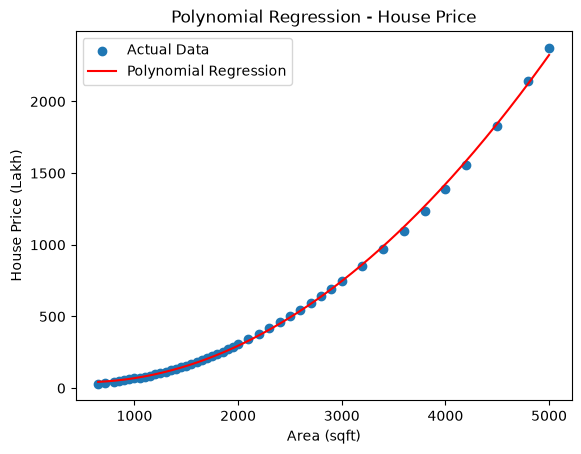

In [20]:
import matplotlib.pyplot as plt

# Generate smooth values
X_curve = np.linspace(
    X["Area_sqft"].min(),
    X["Area_sqft"].max(),
    200
).reshape(-1, 1)

X_curve_df = pd.DataFrame(
    X_curve,
    columns=["Area_sqft"]
)

X_curve_poly = poly.transform(X_curve_df)

y_curve = model.predict(X_curve_poly)

# Plot
plt.scatter(
    X["Area_sqft"],
    y,
    label="Actual Data"
)

plt.plot(
    X_curve,
    y_curve,
    label="Polynomial Regression",
    color="red"
)

plt.xlabel("Area (sqft)")
plt.ylabel("House Price (Lakh)")
plt.title("Polynomial Regression - House Price")

plt.legend()
plt.show()